In [1]:
import torch

from dataset_loaders import build_data_loaders
from models.autoencoder import AbstractAutoencoder
from utils.checkpoints import load_ae_from_path, load_from_wandb
from utils.config import DatasetConfig
from utils.visualisation import plot_latent_space, show

In [2]:
ae_path = load_from_wandb("autoencoder_mnist")
ae = load_ae_from_path(ae_path, device=torch.device("mps"))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/jakob/.netrc.


Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_mnist_beta8.0.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_mnist:latest


In [3]:
dataset_cfg = DatasetConfig(
    name="mnist",
    channels=3,
    height=28,
    width=28,
    num_classes=10,
)

dataloader, test_loader = build_data_loaders(dataset_cfg, batch_size=64)

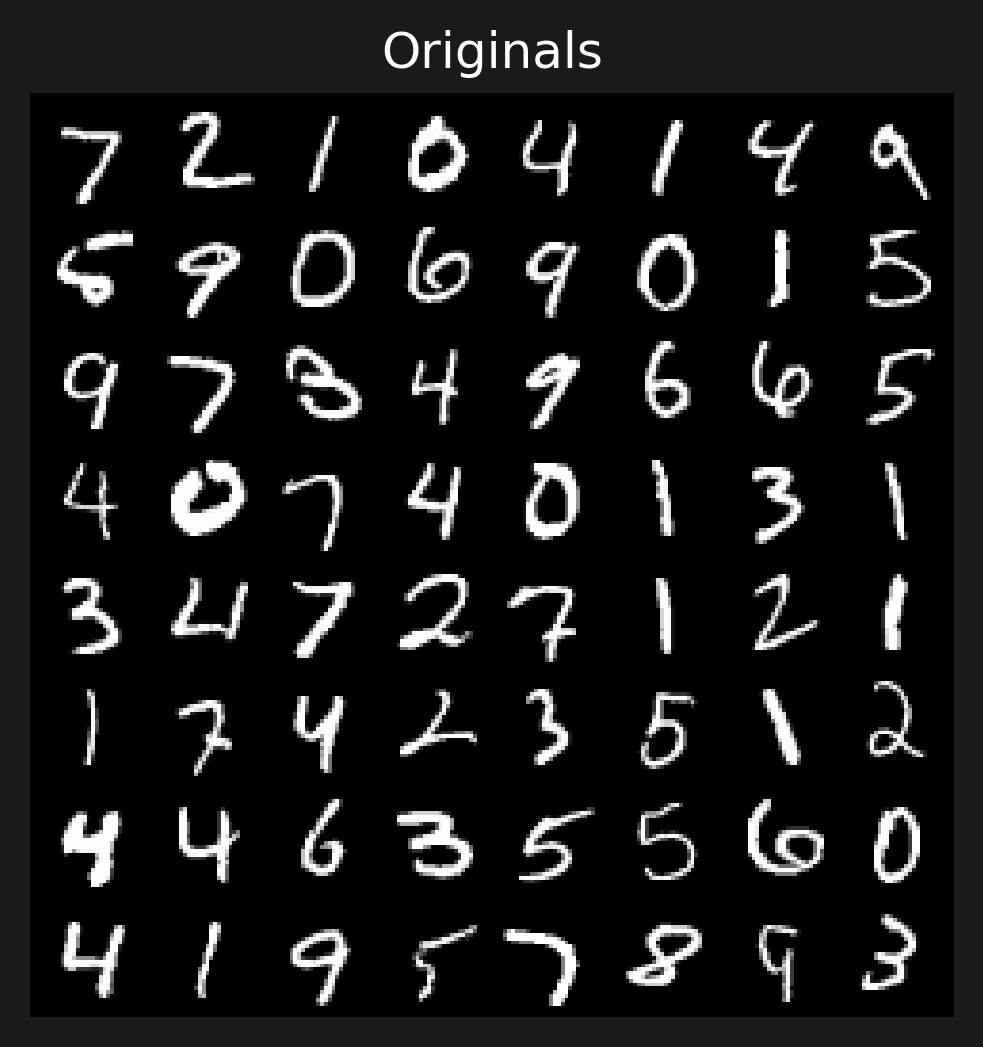

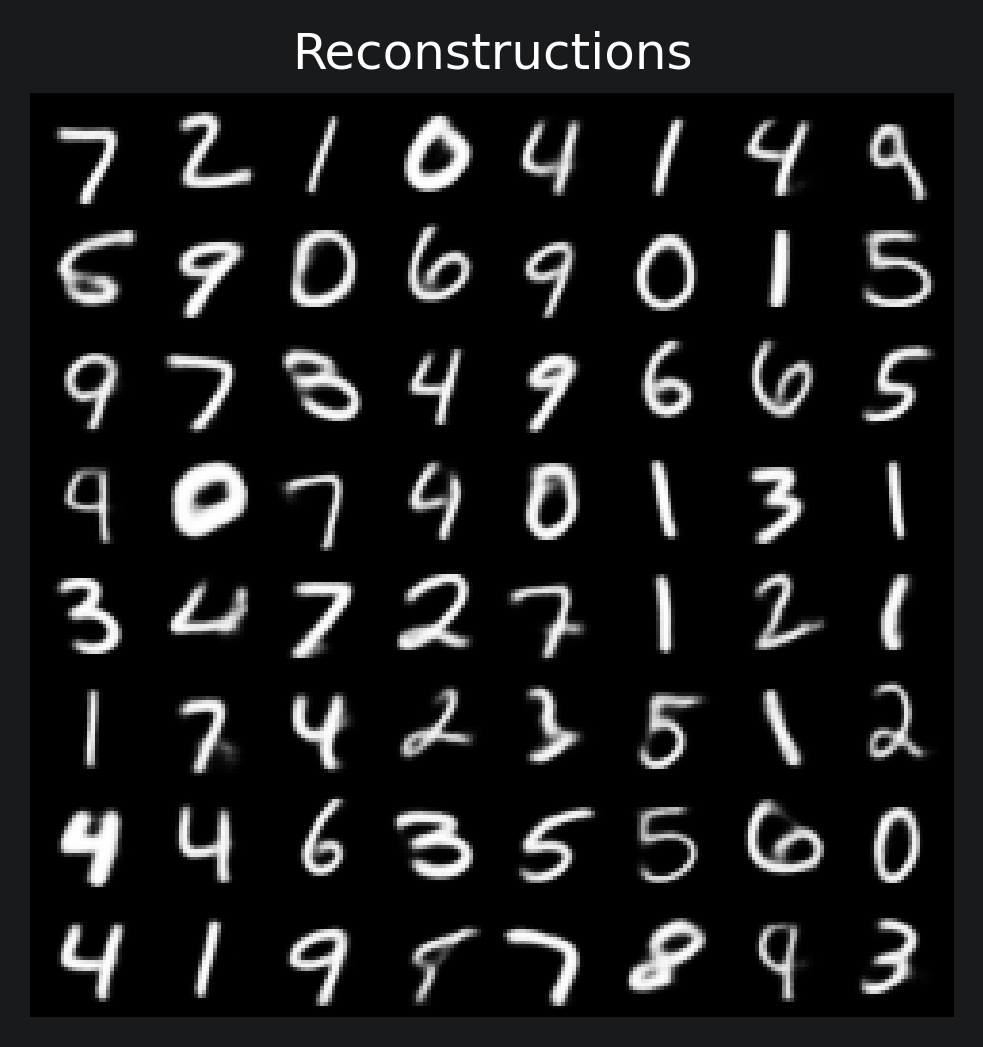

In [4]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    recon, mu, logvar = ae(images)

show(images, "Originals")
show(recon, "Reconstructions")


In [5]:
def ae_latent_space(model: AbstractAutoencoder, data_loader: torch.utils.data.DataLoader,
                    title="Latent Space of MNIST Autoencoder"):
    samples = []
    sampled_labels = []
    for image, label in data_loader:
        latent = model.encode(image)
        samples.append(latent)
        sampled_labels.append(label)

    samples = torch.cat(samples, dim=0)
    sampled_labels = torch.cat(sampled_labels, dim=0)
    plot_latent_space(samples, sampled_labels, title=title)

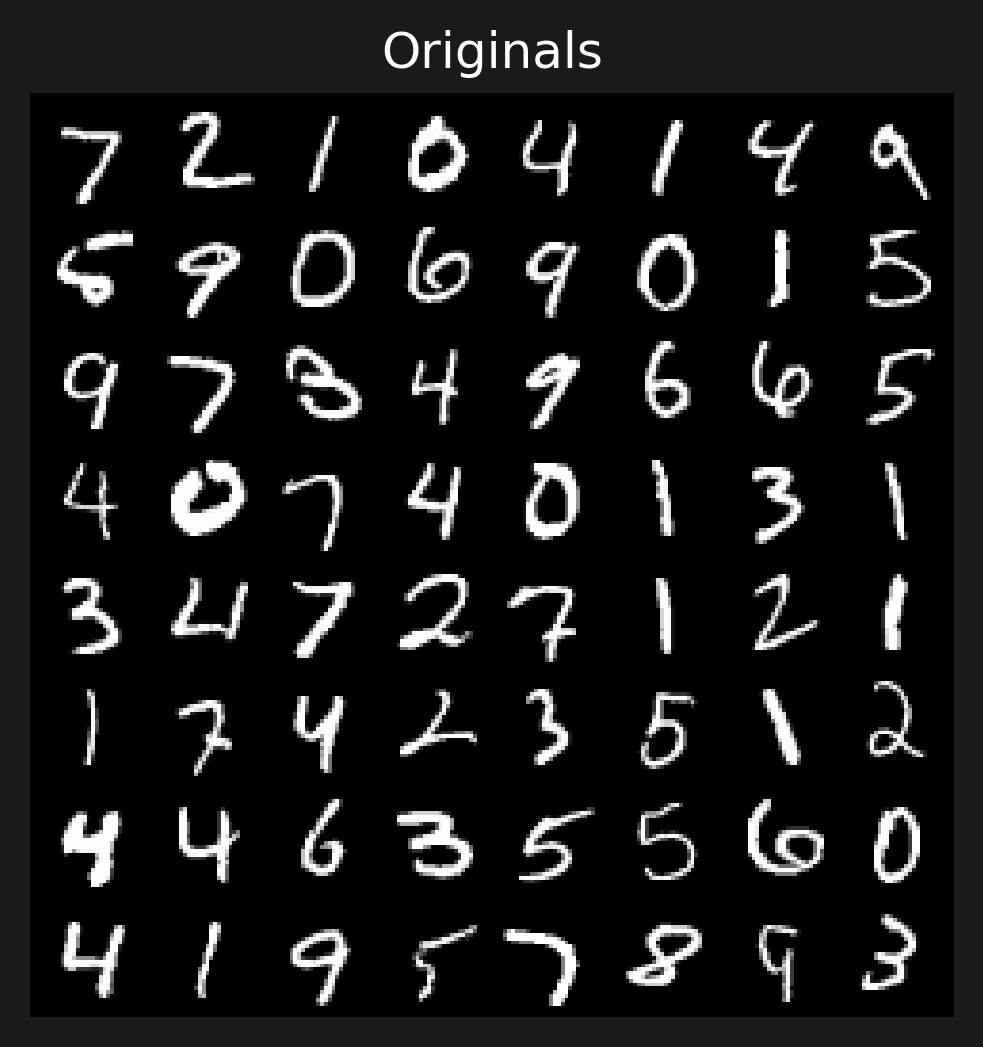

Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_mnist.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_mnist:v5


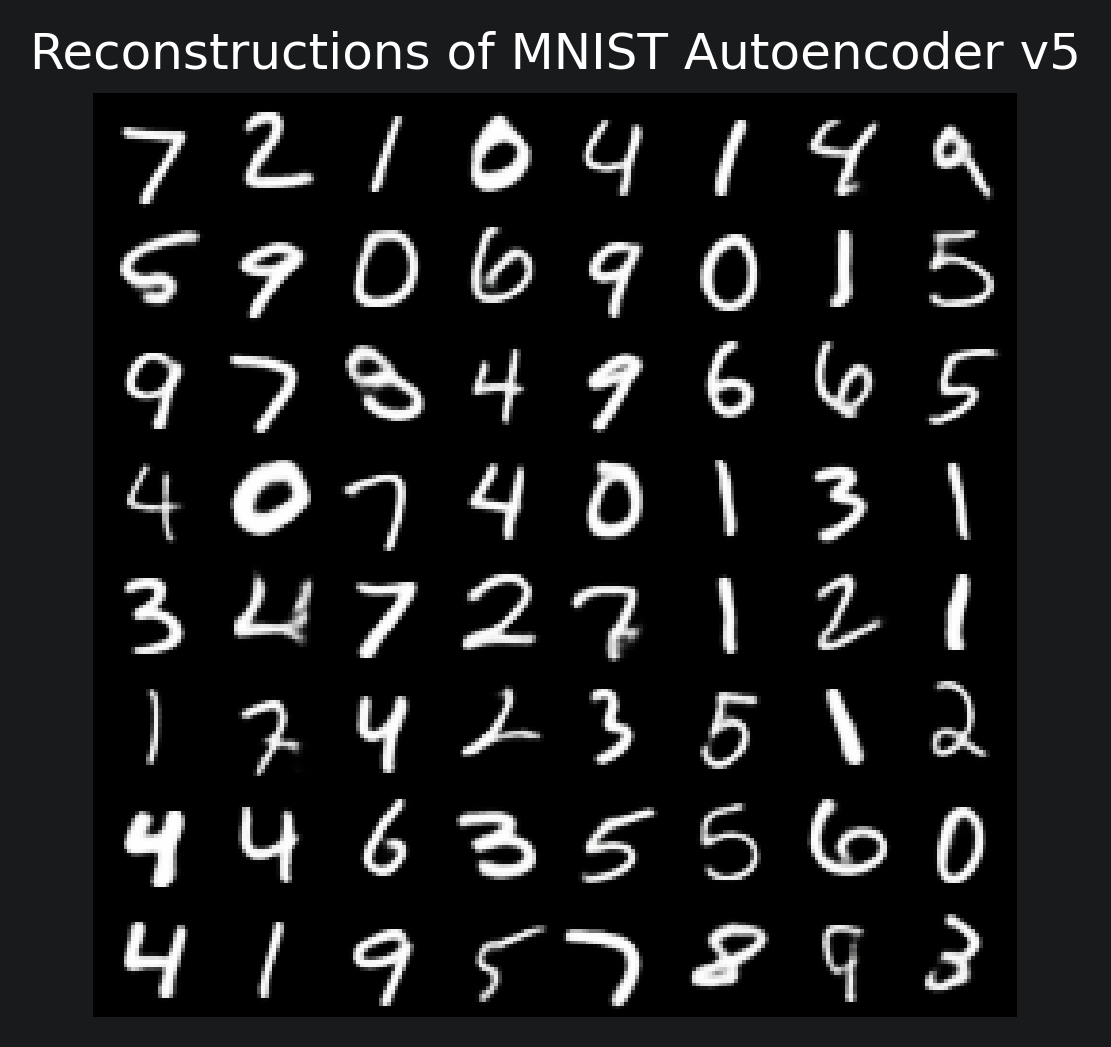

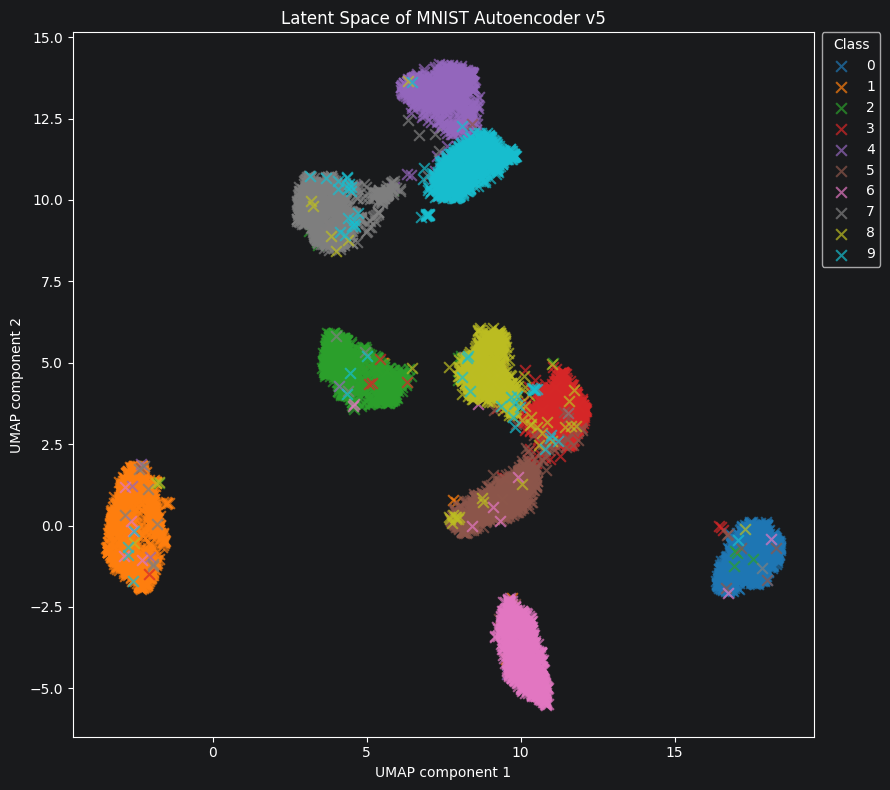

Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_mnist.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_mnist:v6


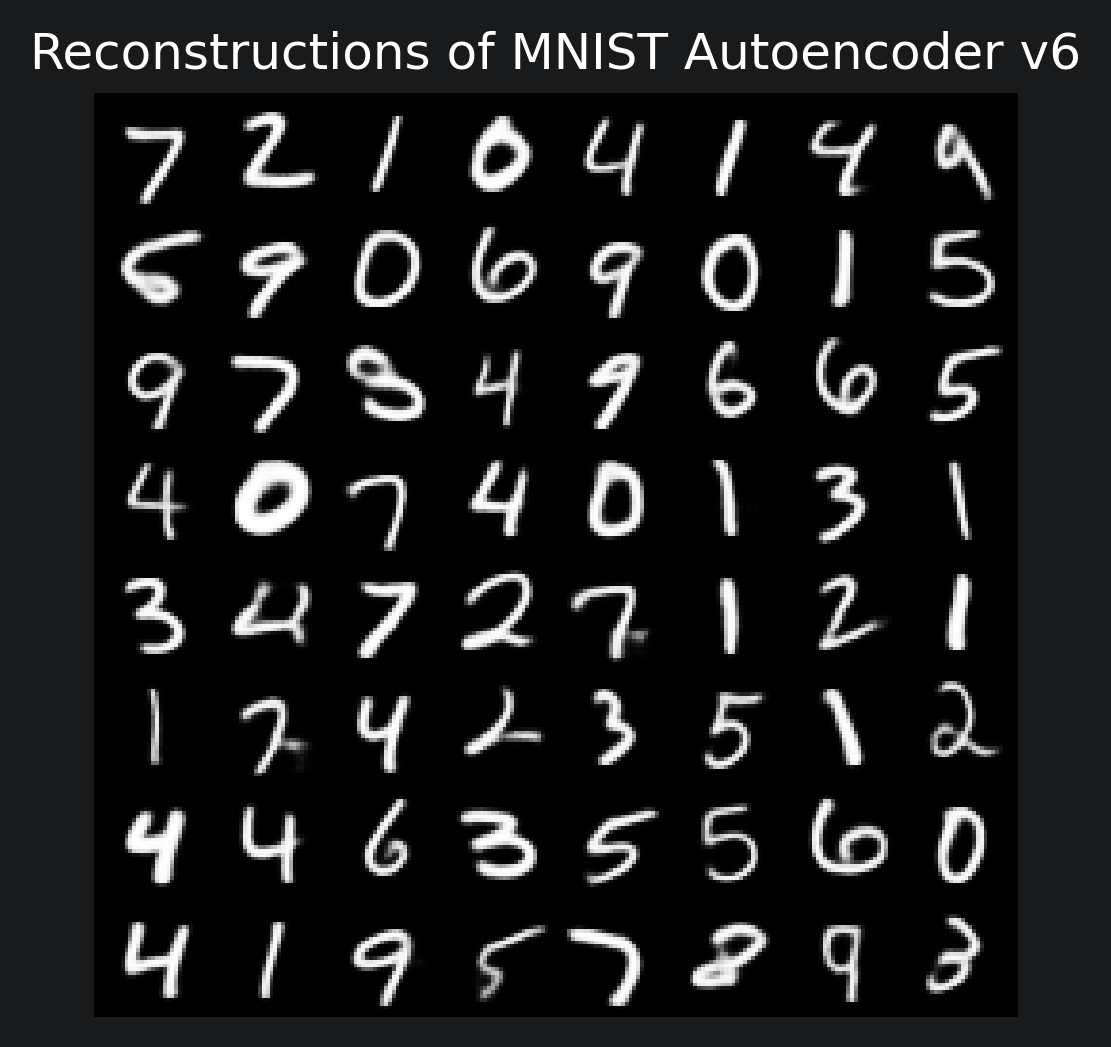

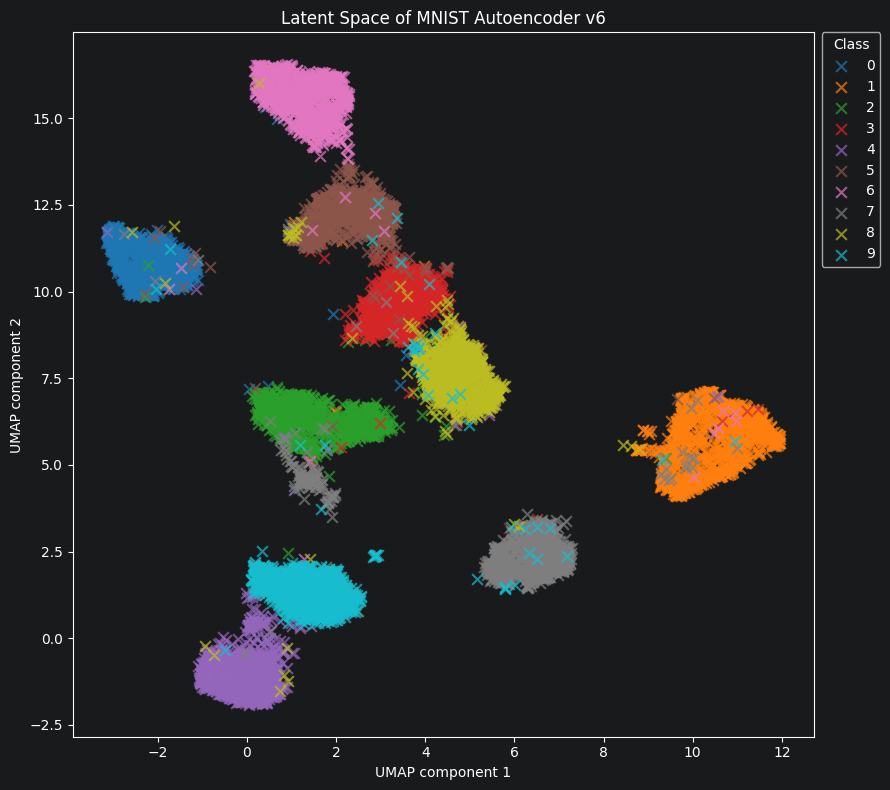

Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_mnist.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_mnist:v7


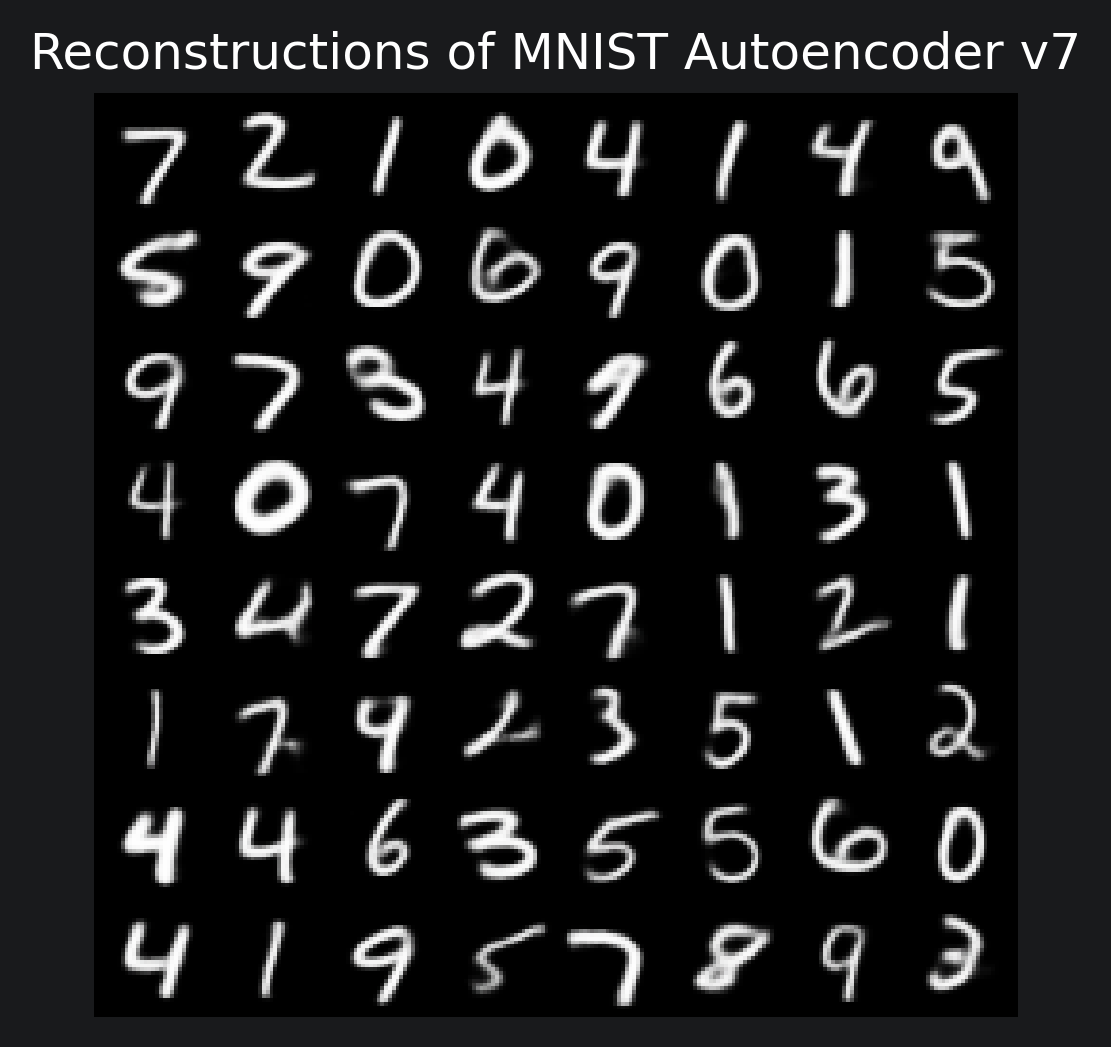

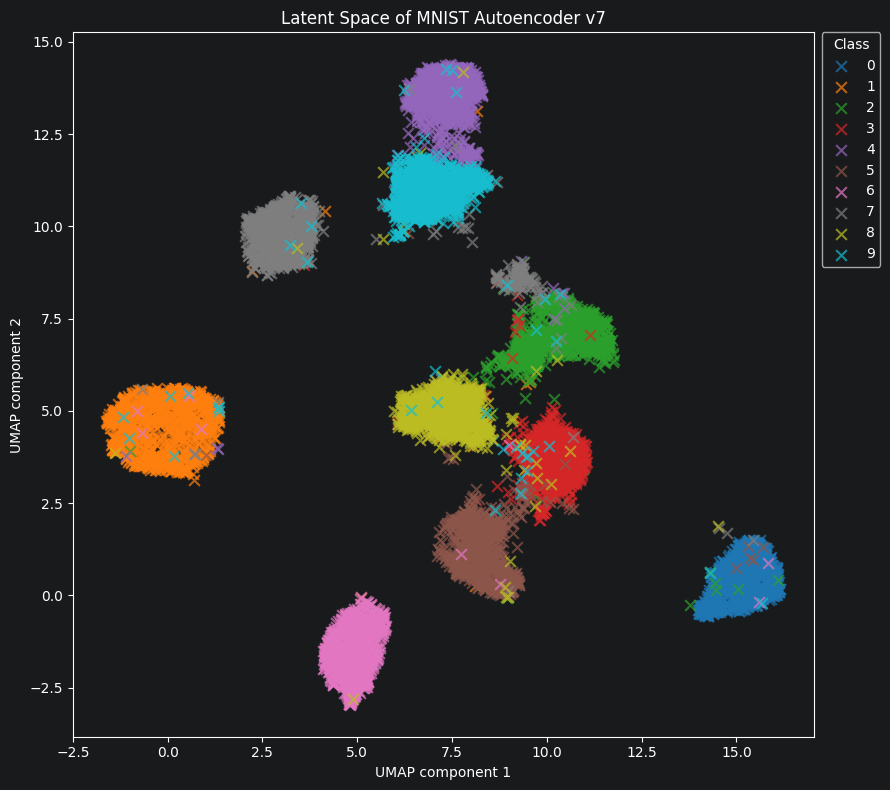

In [6]:
versions = ["v5", "v6", "v7"]
show(images, "Originals")
for version in versions:
    ae_tmp_path = load_from_wandb(f"autoencoder_mnist", tag=version)
    ae_tmp = load_ae_from_path(ae_tmp_path, device=torch.device("mps"))
    with torch.no_grad():
        recon, mu, logvar = ae_tmp(images)
        show(recon, f"Reconstructions of MNIST Autoencoder {version}")
        ae_latent_space(ae_tmp, test_loader, title=f"Latent Space of MNIST Autoencoder {version}")